1.SE BUSCARA VER DE MANERA GRAFICA LA SIMETRIA DEL ESPACIO DE ESFUERZOS PRINCIPALES
<br>
<br>
se asumira que el material es isotropo, es decir que teniendo un estado de esfuerzos principales, no importa
<br>
el orden ni las posibles coninaciones de estos esfuerzos en el solido estas ocasionaran la falla cuando f(sigma)=k
<br>
esta es la frontera, cuando la trayectoria de esfuerzos de cada combinacion toque la frontera es porque f(sigma)=k y fallo
<br>
dentro de la frontera se encontrara en un rango elastico
<br>
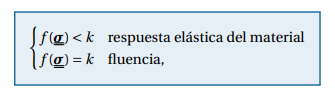
<br>
2.SE PROYECTARAN LAS TRAYECTORIAS SOBRE EL PLANO PI
<br>
<br>
esto es para visualizar los 6 estados en 2 dimensiones en vez de 6, como se hara?? proyectando cada punto sobre el plano pi,
<br>
para ello se debe tener un sistema de coordenadas sobre el plano pi que en otro codigo se demostrara, por ultimo se graficara

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import numpy as np
import matplotlib as mt
import sympy as sp

#1 defino los esfuerzos principales
sigma1=5
sigma2=1
sigma3=-1

#se crea una matriz con las 6 posibles convinaciones
sigma = sp.Matrix([
    [sigma1, sigma2, sigma3],  # Permutación 1
    [sigma1, sigma3, sigma2],  # Permutación 2
    [sigma2, sigma1, sigma3],  # Permutación 3
    [sigma2, sigma3, sigma1],  # Permutación 4
    [sigma3, sigma1, sigma2],  # Permutación 5
    [sigma3, sigma2, sigma1]   # Permutación 6
])
display(sigma)
print("---------------------------------------------------------------------------------------------------------")

Matrix([
[ 5,  1, -1],
[ 5, -1,  1],
[ 1,  5, -1],
[ 1, -1,  5],
[-1,  5,  1],
[-1,  1,  5]])

---------------------------------------------------------------------------------------------------------


AHORA USANDO LOS SIGUIENETS VECTORES UNITARIOS QUE REPRESENTAN EL SISTEMA DE COORDENDAS DEL PLANO PI
<br>
SE PROYECTARAN LAS COMBINACIONES ANTERIORES
<br>
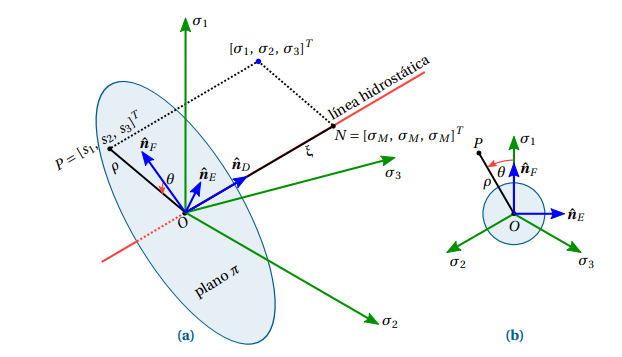
<br>
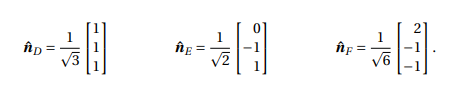
<br>
CUANDO SE PROYECTA SE TIENE LO SIGUIENTE:
<br>
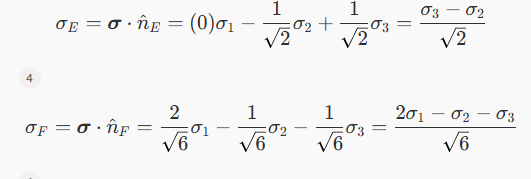
<br>
EL VECTOR ND NO SE USARA PORQUE ES LA PARTE HIDROESTATICA, APLICAREMOS LA ANTERIOR FORMULA

In [41]:
##se almacenaran los resultados en dos listas vacias
Se=[]
Sf=[]
display(sigma)

i=0
filas=6

for i in range(6):  
    s1=sigma[i,0]
    s2=sigma[i,1]
    s3=sigma[i,2]
    
    se_i = (s3 - s2) / (2**(1/2))
    sf_i = (2*s1 - s2 - s3) / (6**(1/2))
    
    Se.append(se_i)
    Sf.append(sf_i)
    
SE=sp.Matrix(Se)
SF=sp.Matrix(Sf)    
display(SE,SF)
    
#display(Se)

Matrix([
[ 5,  1, -1],
[ 5, -1,  1],
[ 1,  5, -1],
[ 1, -1,  5],
[-1,  5,  1],
[-1,  1,  5]])

Matrix([
[-1.41421356237309],
[ 1.41421356237309],
[-4.24264068711928],
[ 4.24264068711928],
[-2.82842712474619],
[ 2.82842712474619]])

Matrix([
[  4.08248290463863],
[  4.08248290463863],
[-0.816496580927726],
[-0.816496580927726],
[  -3.2659863237109],
[  -3.2659863237109]])

In [42]:

# otra manera
sE = (sigma[:,2] - sigma[:,1])/(2**(1/2))
sF = (2*sigma[:,0] - sigma[:,1] - sigma[:,2])/(6**(1/2))
display(sE,sF)

Matrix([
[-1.41421356237309],
[ 1.41421356237309],
[-4.24264068711928],
[ 4.24264068711928],
[-2.82842712474619],
[ 2.82842712474619]])

Matrix([
[  4.08248290463863],
[  4.08248290463863],
[-0.816496580927726],
[-0.816496580927726],
[  -3.2659863237109],
[  -3.2659863237109]])

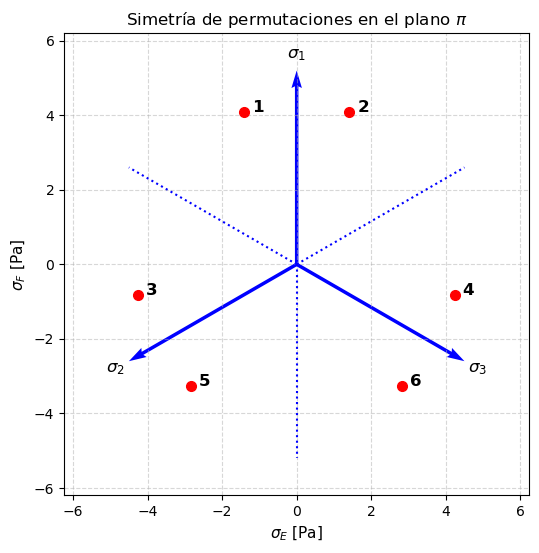

In [48]:
##creamos el grafico (generado con IA)


import matplotlib.pyplot as plt
import numpy as np

# 1. Determinamos la escala L de los ejes
try:
    L = np.linalg.norm([sigma1, sigma2, sigma3])
except NameError:
    # Si no están definidas en la celda, calcula L desde la distancia máxima en Se y Sf
    L = np.max(np.sqrt(np.array(Se)**2 + np.array(Sf)**2))

# 2. Inicializamos la figura con proporción 1:1
plt.figure(figsize=(6, 6))

# 3. Dibujamos los tres ejes proyectados en el plano pi (a 90°, 210° y 330°)
angulos_deg = [90, 210, 330]
etiquetas = [r'$\sigma_1$', r'$\sigma_2$', r'$\sigma_3$']

for ang, etiq in zip(angulos_deg, etiquetas):
    ang_rad = np.deg2rad(ang)
    
    # Semieje positivo (flecha azul)
    plt.quiver(0, 0, L*np.cos(ang_rad), L*np.sin(ang_rad), 
               color='b', angles='xy', scale_units='xy', scale=1)
    
    # Prolongación negativa (línea azul punteada)
    plt.plot([0, L*np.cos(ang_rad + np.pi)], [0, L*np.sin(ang_rad + np.pi)], 
             color='b', linestyle=':')
    
    # Nombre del eje
    plt.text(1.08*L*np.cos(ang_rad), 1.08*L*np.sin(ang_rad), etiq, 
             horizontalalignment='center', verticalalignment='center', fontsize=12)

# 4. Graficamos los puntos contenidos en Se y Sf (puntos rojos)
plt.plot(Se, Sf, 'ro', markersize=7)

# 5. Numeramos los puntos del 1 al 6 mediante un ciclo for
for i in range(len(Se)):
    plt.text(Se[i] + 0.04*L, Sf[i], str(i + 1), fontsize=12, fontweight='bold')

# 6. Formato visual de la gráfica
plt.axis('equal')
plt.axis([-1.2*L, 1.2*L, -1.2*L, 1.2*L])
plt.xlabel(r'$\sigma_E$ [Pa]', fontsize=11)
plt.ylabel(r'$\sigma_F$ [Pa]', fontsize=11)
plt.title(r'Simetría de permutaciones en el plano $\pi$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Desplegar la imagen
plt.show()
